# Tree-Based Model Cost-Sensitive Learning

In [1]:
import os
from datetime import datetime
from pathlib import Path

import boto3
import botocore.exceptions
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import sklearn.ensemble as skens
import sklearn.metrics as mtr
import sklearn.model_selection as mds
import sklearn.preprocessing as pp
import xgboost as xgb
from dotenv import load_dotenv
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import sklearn.utils as skut

In [2]:
PROJ_ROOT = Path.cwd().parent

In [3]:
assert load_dotenv(dotenv_path=PROJ_ROOT.parent / '.env')

In [4]:
import cc_churn.visualization as vzu
import r2.io_utils as r2io
from cc_churn.evaluation import evaluate_model
from cc_churn.scoring import get_scorers
from cc_churn.tuning import tune_threshold_cv

## About

Machine Learning (ML) model training using tree-based models.

### Outputs

Same as in `04_model_development__cost_sensitive_learning__linear_models`.

## User Inputs

In [5]:
# R2 data bucket details
bucket_name = 'cc-churn-splits'
# # name of train data key (file) in private R2 bucket
r2_key_train = 'train_data.parquet.gzip'
# # name of validation data key (file) in private R2 bucket
r2_key_val = 'validation_data.parquet.gzip'
# # name of test data key (file) in private R2 bucket
r2_key_test = 'test_data.parquet.gzip'

# datatypes for categorical columns
dtypes_categoricals = {
    "gender": 'string[pyarrow]',
    "marital_status": 'string[pyarrow]',
    "income_category": 'string[pyarrow]',
    "card_category": 'string[pyarrow]',
    "education_level": 'string[pyarrow]',
}

# EDA
threshold_correlation = 0.55

# model development
# # model validation
n_cv_folds = 5
primary_metric_val = 'prauc'
metrics_list_val = ['prauc', 'f2', 'recall', 'rocauc']
# # model evaluation
primary_metric_eval = 'f2'
metrics_list_eval = ['f2', 'recall']
threshold_overfit = 5

label = 'is_churned'

# costs
# # revenue from transactions (bank earns #% of transaction volume)
interchange_rate = 0.02
# # revenue from revolving balance (~20% interest)
apr = 0.18
# # fee revenue from credit card exposure (modeled from card type)
card_fees = {"Blue": 0, "Silver": 50, "Gold": 100, "Platinum": 200}
tenure_years = 3
discount = 0.9
# # percentage of churners who can be convinced to stay (i.e. success rate
# # of saving a churning customer)
success_rate = 0.40
# # cost of intervention to get a single customer to not churn (discounts,
# # call center time, retention offers, etc.)
intervention_cost = 50

multiplier = (1 - discount**tenure_years) / (1 - discount)

In [6]:
account_id = os.getenv('ACCOUNT_ID')
access_key_id = os.getenv('ACCESS_KEY_ID_USER2')
secret_access_key = os.getenv('SECRET_ACCESS_KEY_USER2')

scorers_val = get_scorers(metrics_list_val)
scorers_eval = get_scorers(metrics_list_eval)

s3_client = boto3.client(
    's3',
    endpoint_url=f'https://{account_id}.r2.cloudflarestorage.com',
    aws_access_key_id=access_key_id,
    aws_secret_access_key=secret_access_key,
    region_name='auto'
)

## Load Data

### Data for Model Validation

Load the training data

In [7]:
%%time
df_train = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_train)
    .astype(dtypes_categoricals)
)
print(f"Loaded {len(df_train):,} rows of training data")
with pd.option_context('display.max_columns', None):
    display(df_train.head())

Loaded 6,285 rows of training data


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,714283458,0,40,M,2,College,Single,$80K - $120K,Blue,36,5,1,4,14544.0,0.0,14544.0,0.768,4064.0,92,0.769,0.0
1,787587033,0,42,F,4,Graduate,Single,Less than $40K,Blue,32,3,1,2,2996.0,1992.0,1004.0,0.948,4463.0,87,0.74,0.665
2,714672933,0,52,F,3,Graduate,Married,$40K - $60K,Blue,36,6,4,2,3143.0,2268.0,875.0,0.801,4417.0,84,0.68,0.722
3,714974658,0,48,F,4,College,Married,Less than $40K,Blue,36,6,1,4,2464.0,1867.0,597.0,0.6,1219.0,35,1.333,0.758
4,712049208,0,56,M,3,Post-Graduate,Married,$60K - $80K,Blue,39,3,1,2,3955.0,2517.0,1438.0,0.484,1238.0,25,1.083,0.636


CPU times: user 98.8 ms, sys: 18 ms, total: 117 ms
Wall time: 218 ms


### Data for Model Evaluation

Load the validation data

In [8]:
%%time
df_val = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_val)
    .astype(dtypes_categoricals)
)
print(f"Loaded {len(df_val):,} rows of validation data")
with pd.option_context('display.max_columns', None):
    display(df_val.head())

Loaded 1,693 rows of validation data


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,823840458,0,47,F,1,High School,Married,Unknown,Blue,43,4,2,2,1828.0,1517.0,311.0,0.661,4542.0,82,0.577,0.83
1,716328558,0,46,M,2,Uneducated,Married,$80K - $120K,Blue,38,4,5,2,11434.0,0.0,11434.0,0.84,4520.0,83,0.844,0.0
2,714735033,0,45,F,5,Doctorate,Married,Less than $40K,Blue,34,4,2,2,1438.3,491.0,947.3,0.708,4376.0,84,0.787,0.341
3,712163433,1,47,M,3,Uneducated,Married,$40K - $60K,Blue,29,1,2,4,1684.0,644.0,1040.0,0.723,2164.0,36,0.714,0.382
4,720307683,0,43,F,4,Graduate,Divorced,Less than $40K,Blue,36,3,2,2,1438.3,743.0,695.3,0.624,4484.0,78,0.625,0.517


CPU times: user 43.4 ms, sys: 2.27 ms, total: 45.6 ms
Wall time: 173 ms


Get the combined training+validation data split

In [9]:
%%time
df_train_val = pd.concat([df_train, df_val], ignore_index=True)
print(f"Obtained {len(df_train_val):,} rows of training+validation data")
with pd.option_context('display.max_columns', None):
    display(df_train_val.head())

Obtained 7,978 rows of training+validation data


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,714283458,0,40,M,2,College,Single,$80K - $120K,Blue,36,5,1,4,14544.0,0.0,14544.0,0.768,4064.0,92,0.769,0.0
1,787587033,0,42,F,4,Graduate,Single,Less than $40K,Blue,32,3,1,2,2996.0,1992.0,1004.0,0.948,4463.0,87,0.74,0.665
2,714672933,0,52,F,3,Graduate,Married,$40K - $60K,Blue,36,6,4,2,3143.0,2268.0,875.0,0.801,4417.0,84,0.68,0.722
3,714974658,0,48,F,4,College,Married,Less than $40K,Blue,36,6,1,4,2464.0,1867.0,597.0,0.6,1219.0,35,1.333,0.758
4,712049208,0,56,M,3,Post-Graduate,Married,$60K - $80K,Blue,39,3,1,2,3955.0,2517.0,1438.0,0.484,1238.0,25,1.083,0.636


CPU times: user 15.1 ms, sys: 1.01 ms, total: 16.1 ms
Wall time: 14.7 ms


Load the test data

In [10]:
%%time
df_test = (
    r2io.pandas_read_parquet_r2(s3_client, bucket_name, r2_key_test)
    .astype(dtypes_categoricals)
)
print(f"Loaded {len(df_test):,} rows of test data")
with pd.option_context('display.max_columns', None):
    display(df_test)

Loaded 2,149 rows of test data


,clientnum,is_churned,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,708223383,1,47,F,3,High School,Married,Unknown,Blue,39,6,3,4,11410.0,979.0,10431.0,1.049,2736.0,38,0.462,0.086
1,715052583,0,45,M,3,Doctorate,Single,$60K - $80K,Silver,34,3,3,1,27494.0,879.0,26615.0,0.671,14375.0,112,0.672,0.032
2,719910333,0,43,F,3,Unknown,Unknown,Less than $40K,Blue,36,4,4,2,5853.0,1190.0,4663.0,0.936,3595.0,80,0.667,0.203
3,785328408,0,37,F,4,Graduate,Married,Less than $40K,Blue,31,5,2,3,1758.0,1180.0,578.0,0.744,2013.0,41,0.367,0.671
4,716321583,0,50,F,3,Unknown,Single,$40K - $60K,Blue,36,5,3,3,12740.0,1173.0,11567.0,1.04,3441.0,55,0.719,0.092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,817247658,0,45,M,3,High School,Unknown,$60K - $80K,Blue,27,6,2,3,21317.0,0.0,21317.0,0.833,3814.0,67,1.03,0.0
2145,816834933,0,34,F,4,Graduate,Single,Unknown,Silver,29,6,2,2,30702.0,673.0,30029.0,0.721,2652.0,64,0.524,0.022
2146,790221633,0,44,F,4,Graduate,Single,$40K - $60K,Blue,38,3,3,3,3897.0,2296.0,1601.0,0.746,4627.0,77,0.791,0.589
2147,719535558,0,47,M,4,College,Divorced,$40K - $60K,Blue,36,5,1,1,5570.0,1858.0,3712.0,0.783,4129.0,72,0.636,0.334


CPU times: user 22.6 ms, sys: 6.23 ms, total: 28.8 ms
Wall time: 105 ms


## Separate Features from Target

In [11]:
# model validation
X_train = df_train.drop(columns=[label])
y_train = df_train[label]

X_val = df_val.drop(columns=[label])
y_val = df_val[label]

# model evaluation
X_train_val = df_train_val.drop(columns=[label])
y_train_val = df_train_val[label]

X_test = df_test.drop(columns=[label])
y_test = df_test[label]

# model inference
X_all = pd.concat([X_train, X_val, X_test])
y_all = pd.concat([y_train, y_val, y_test])

## EDA

Show the class imbalance

In [12]:
display(y_train.value_counts(normalize=True).to_frame())

,proportion
is_churned,
0,0.8393
1,0.1607


Use the class imbalance to get the class_weights for cost-sensitive learning

In [13]:
# utilize inverse of class distribution (class imbalance ratio)
class_weights_train = skut.class_weight.compute_class_weight(
    class_weight="balanced",
    classes=y_train.squeeze().unique().to_numpy(),
    y=y_train.squeeze().to_numpy(),
)
class_weights_train = {c:float(w) for w, c in zip(class_weights_train, [0,1])}

class_weights_train

{0: 0.5957345971563981, 1: 3.1113861386138613}

Get the correlation between all numerical features and show combinations of features that are correlated

In [14]:
%%time
df_corr = X_train[
    list(X_train.select_dtypes(['int64', 'double']))
].corr()

# Filter for high correlations by absolute value
high_corr_pairs = []
for i in range(len(df_corr.columns)):
    for j in range(i + 1, len(df_corr.columns)):
        col1 = df_corr.columns[i]
        col2 = df_corr.columns[j]
        corr_value = df_corr.loc[col1, col2]
        if abs(corr_value) > threshold_correlation:
            high_corr_pairs.append(
                {'feat_1': col1, 'feat_2': col2, 'correlation': corr_value}
            )
df_correlated_features = (
    pd.DataFrame.from_records(high_corr_pairs)
    .sort_values(by=['correlation'], ascending=False, ignore_index=True)
)
display(df_correlated_features)

,feat_1,feat_2,correlation
0,credit_limit,avg_open_to_buy,0.995847
1,total_revolv_bal,avg_utilization_ratio,0.629318


CPU times: user 5.57 ms, sys: 0 ns, total: 5.57 ms
Wall time: 5.3 ms


Show the number of unique values in all categorical and ordinal features

In [15]:
(
    X_train[list(X_train.select_dtypes(['string']))]
    .nunique()
    .reset_index()
    .rename(columns={'index': 'feature_name', 0: 'num_unique_values'})
)

,feature_name,num_unique_values
0,gender,2
1,education_level,7
2,marital_status,4
3,income_category,6
4,card_category,4


## Model Validation

### Feature Selection

Define ordinal, categorical and numerical features, excluding correlated features

In [16]:
ordinal_features = [
    'income_category',
    'education_level',
]
categorical_features = [
    'card_category',
    'marital_status',
]
numeric_features = [
    'customer_age',
    'dependent_count',
    'months_on_book',
    'num_products',
    'months_inactive_12_mon',
    'contacts_count_12_mon',
    'total_revolv_bal',
    'avg_open_to_buy',
    'total_amt_chng_q4_q1',
    'total_trans_amt',
    'total_trans_ct',
    'total_ct_chng_q4_q1',
    'avg_utilization_ratio',
]
features = numeric_features+ordinal_features#+categorical_features

Verify no correlated features have been selected

In [17]:
for _, row in df_correlated_features.iterrows():
    feats_corr = row[['feat_1', 'feat_2']].tolist()
    try:
        assert len(
            set(feats_corr).intersection(set(features))
        ) <= 1
    except AssertionError as e:
        print(feats_corr)

['total_revolv_bal', 'avg_utilization_ratio']


In [18]:
numeric_transformer = Pipeline(
    steps = [('scaler', pp.MinMaxScaler())]
)
categorical_transformer = Pipeline(
    steps=[
        ("ohe", pp.OneHotEncoder(handle_unknown="ignore", drop='if_binary'))
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        (
            "oe",
            pp.OrdinalEncoder(
                categories=[
                    [
                        'Unknown',
                        'Less than $40K',
                        '$40K - $60K',
                        '$60K - $80K',
                        '$80K - $120K',
                        '$120K +'
                    ],
                    [
                        'Unknown', 
                        'Uneducated', 
                        'High School', 
                        'College', 
                        'Graduate', 
                        'Post-Graduate', 
                        'Doctorate'
                    ],
                ],
                handle_unknown="use_encoded_value",
                dtype=np.float64,
                unknown_value=np.nan,
            )
        ),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        # ("cat", categorical_transformer, categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
    n_jobs=-1,
)
clf_inputs = dict(
    features=features,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    sample_weights=None,
)

In [19]:
models = {
    'LogisticRegression_imbalanced': LogisticRegression(
        class_weight=None, random_state=42, n_jobs=-1
    ),
    'LogisticRegression': LogisticRegression(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'HistGradientBoostingClassifier': skens.HistGradientBoostingClassifier(
        # # VERSION 1
        # max_depth=3,
        # max_bins=255,
        # l2_regularization=0.25,
        # learning_rate=0.1,
        # max_iter=250,
        # class_weight=class_weights,
        # random_state=42,
        # # VERSION 2
        max_depth=3,
        l2_regularization=0.25,
        class_weight='balanced',
        random_state=42,
    ),
    'RandomForestClassifier': skens.RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'XGBClassifier': xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        gamma=20,
        max_depth=0,
        eta=0.05,
        min_child_weight=15,
        scale_pos_weight=class_weights_train[1]/class_weights_train[0],
        random_state=42,
        n_jobs=-1,
    ),
    'Ensemble__VotingClassifier': skens.VotingClassifier(
        estimators=[
            (
                'lr',
                LogisticRegression(
                    class_weight='balanced', random_state=42, n_jobs=-1
                ),
            ),
            (
                'hbc', skens.HistGradientBoostingClassifier(
                    max_depth=3,
                    l2_regularization=0.25,
                    class_weight='balanced',
                    random_state=42,
                ),
            ),
            (
                'rf', skens.RandomForestClassifier(
                    n_estimators=300,
                    max_depth=3,
                    class_weight='balanced',
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
            (
                    'xgb', xgb.XGBClassifier(
                    objective='binary:logistic',
                    eval_metric='logloss',
                    # # VERSION 1
                    # gamma=15,
                    # max_depth=0,
                    # # min_child_weight=7,
                    # # VERSION 2
                    gamma=20,
                    max_depth=0,
                    eta=0.05,
                    min_child_weight=15,
                    scale_pos_weight=(
                        class_weights_train[1]/class_weights_train[0]
                    ),
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ],
        voting='soft',
    )
}

In [20]:
%%time
cv_results_tuned_models = {
    model_name_param: tune_threshold_cv(
        preprocessor,
        model,
        model_name_param,
        n_cv_folds,
        scorers_val,
        primary_metric_val,
        features,
        X_train,
        y_train,
    )
    for model_name_param, model in models.items()
    if 'Dummy' not in model_name_param
}

(LogisticRegression_imbalanced) Start: 2026-03-27 11:08:43...done at 2026-03-27 11:08:45 (2.32 s).
(LogisticRegression) Start: 2026-03-27 11:08:45...done at 2026-03-27 11:08:47 (1.97 s).
(HistGradientBoostingClassifier) Start: 2026-03-27 11:08:47...done at 2026-03-27 11:08:49 (2.30 s).
(RandomForestClassifier) Start: 2026-03-27 11:08:49...done at 2026-03-27 11:08:55 (5.36 s).
(XGBClassifier) Start: 2026-03-27 11:08:55...done at 2026-03-27 11:08:56 (1.16 s).
(Ensemble__VotingClassifier) Start: 2026-03-27 11:08:56...done at 2026-03-27 11:09:03 (6.84 s).
CPU times: user 1.62 s, sys: 29.1 ms, total: 1.65 s
Wall time: 20 s


In [21]:
df_cv_scores_outer = (
    # best thresholds determined from inner CV and used in outer CV
    pd.DataFrame.from_records(
        [
            {
                'model': m,
                'cv_fold_outer': k,
                'threshold': float(est.best_threshold_),
            }
            for m, v in cv_results_tuned_models.items()
            for k, est in enumerate(v["estimator"], 1)
        ]
    )
    .merge(
        # scores from outer CV
        (
            pd.concat(list(cv_results_tuned_models.values()))
            .assign(cv_fold_outer=lambda df: df.index+1)
            .drop(columns=['estimator'])
            .rename(columns={"model_name": "model", 'fit_time': "train_time"})
            .reset_index(drop=True)
        ),
        on=['model', 'cv_fold_outer'],
        how='left',
    )
)
df_cv_scores_outer

,model,cv_fold_outer,threshold,train_time,score_time,test_prauc,train_prauc,test_f2,train_f2,test_recall,train_recall,test_rocauc,train_rocauc
0,LogisticRegression_imbalanced,1,0.328702,0.833003,0.021626,0.526299,0.497350,0.695266,0.671513,0.698020,0.674505,0.818204,0.803959
1,LogisticRegression_imbalanced,2,0.306801,0.813734,0.022898,0.500000,0.492365,0.687135,0.684632,0.698020,0.698020,0.812517,0.810740
2,LogisticRegression_imbalanced,3,0.377201,0.835095,0.021992,0.467586,0.515523,0.602041,0.648477,0.584158,0.632426,0.766487,0.792872
3,LogisticRegression_imbalanced,4,0.357582,0.792784,0.022749,0.492153,0.504406,0.653041,0.654030,0.648515,0.644802,0.793926,0.795150
4,LogisticRegression_imbalanced,5,0.308827,0.809908,0.022450,0.472942,0.505677,0.659824,0.694309,0.668317,0.706683,0.796244,0.816730
5,LogisticRegression,1,0.725892,0.823548,0.021329,0.535647,0.489836,0.685000,0.659653,0.678218,0.659653,0.813043,0.797244
6,LogisticRegression,2,0.664614,0.840161,0.020922,0.495511,0.490576,0.700576,0.700287,0.722772,0.725248,0.819680,0.819259
7,LogisticRegression,3,0.665036,0.818478,0.022349,0.500105,0.492460,0.710878,0.700957,0.737624,0.725248,0.825684,0.819733
8,LogisticRegression,4,0.705407,0.829367,0.022401,0.473683,0.501843,0.669253,0.683876,0.683168,0.691832,0.801300,0.810845
9,LogisticRegression,5,0.685782,0.827884,0.022019,0.457888,0.496526,0.654704,0.697254,0.668317,0.716584,0.792452,0.817889


In [22]:
df_cv_scores_all = (
    df_cv_scores_outer
    .drop(columns=['cv_fold_outer'])
    .groupby(['model'], as_index=False)
    .mean()
    .convert_dtypes(dtype_backend='pyarrow')
    .assign(
        pct_diff=lambda df: (
            (
                df[f'train_{primary_metric_val}']
                -df[f'test_{primary_metric_val}']
            ).abs()/df[f'train_{primary_metric_val}']*100
        ),
        is_overfit=lambda df: (
            (
                df[f'train_{primary_metric_val}']
                > df[f'test_{primary_metric_val}']
            )
            .astype('bool[pyarrow]')
        ),
        is_overfit_significant=lambda df: (
            (
                (df['is_overfit'] == True)
                & (df['pct_diff'] > threshold_overfit)
            ).astype('bool[pyarrow]')
        ),
    )
    .sort_values(
        by=[f'test_{primary_metric_val}'], ascending=[False], ignore_index=True
    )
)
(
    df_cv_scores_all
    .style
    .set_properties(
        subset=['model']+[f'test_{m}' for m in metrics_list_val],
        **{'background-color': 'yellow', 'color': 'black'}
    )
    .set_properties(
        subset=[f'train_{m}' for m in metrics_list_val],
        **{'background-color': 'teal', 'color': 'white'}
    )
    .set_properties(
        subset=['is_overfit_significant'],
        **{'background-color': 'darkred', 'color': 'white'}
    )
)


,model,threshold,train_time,score_time,test_prauc,train_prauc,test_f2,train_f2,test_recall,train_recall,test_rocauc,train_rocauc,pct_diff,is_overfit,is_overfit_significant
0,HistGradientBoostingClassifier,0.750577,1.076717,0.026940,0.801560,0.872774,0.862341,0.917120,0.850495,0.911139,0.917570,0.950214,8.159398,True,True
1,XGBClassifier,0.760142,1.040217,0.024646,0.778053,0.851575,0.855333,0.915005,0.847525,0.914851,0.913620,0.949369,8.633570,True,True
2,Ensemble__VotingClassifier,0.628649,6.343750,0.089710,0.737487,0.798756,0.847284,0.892576,0.849505,0.898267,0.909207,0.936385,7.670536,True,True
3,RandomForestClassifier,0.598196,5.079581,0.077855,0.545726,0.575415,0.698651,0.723423,0.695050,0.720297,0.820890,0.835457,5.159629,True,True
4,LogisticRegression,0.689346,0.827887,0.021804,0.492567,0.494248,0.684082,0.688405,0.698020,0.703713,0.810432,0.812994,0.340190,True,False
5,LogisticRegression_imbalanced,0.335822,0.816905,0.022343,0.491796,0.503064,0.659461,0.670592,0.659406,0.671287,0.797475,0.803890,2.239953,True,False


In [23]:
best_estimator = (
    df_cv_scores_all
    .nlargest(1, f'test_{primary_metric_val}')
    ['model']
    .squeeze()
)
best_estimator_threshold = (
    df_cv_scores_all
    .query(f"model == '{best_estimator}'")
    ['threshold']
    .squeeze()
)
assert '_imbalanced' not in best_estimator

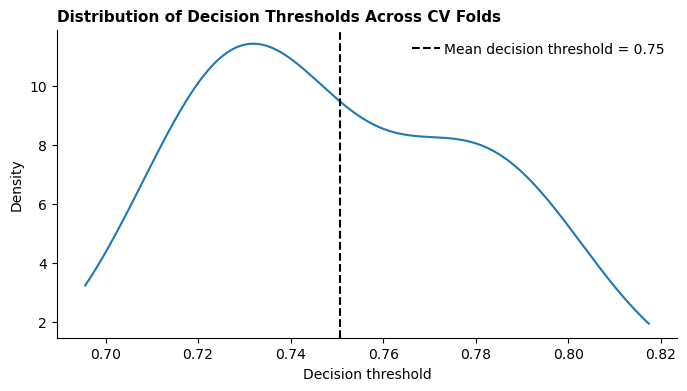

In [24]:
decision_thresholds = pd.Series(
    [
        est.best_threshold_
        for est in cv_results_tuned_models[best_estimator]["estimator"]
    ],
)

fig, ax = plt.subplots(figsize=(8, 4))
ax = decision_thresholds.plot.kde(ax=ax)
ax.axvline(
    decision_thresholds.mean(),
    color="k",
    linestyle="--",
    label=f"Mean decision threshold = {decision_thresholds.mean():.2f}",
)
ax.set_xlabel("Decision threshold")
ax.legend(
    loc="upper right",
    frameon=False,
    handletextpad=0.3,
)
ax.spines[['right', 'top']].set_visible(False)
_ = ax.set_title(
    "Distribution of Decision Thresholds Across CV Folds",
    loc='left',
    fontweight='bold',
    fontsize=11,
)

In [25]:
%%time
_, df_val_pred = evaluate_model(
    preprocessor,
    models[best_estimator],
    best_estimator,
    X_train,
    y_train,
    X_val,
    y_val,
    scorers_eval,
    'balanced',
    primary_metric=primary_metric_eval,
    threshold_overfit=threshold_overfit,
    threshold_scoring=best_estimator_threshold,
)
with pd.option_context('display.max_columns', None):
    display(df_val_pred)

,clientnum,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,num_products,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolv_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,y_pred,y_pred_proba,is_churned,model_name
0,823840458,47,F,1,High School,Married,Unknown,Blue,43,4,2,2,1828.0,1517.0,311.0,0.661,4542.0,82,0.577,0.83,0,0.009399,0,HistGradientBoostingClassifier
1,716328558,46,M,2,Uneducated,Married,$80K - $120K,Blue,38,4,5,2,11434.0,0.0,11434.0,0.84,4520.0,83,0.844,0.0,0,0.025546,0,HistGradientBoostingClassifier
2,714735033,45,F,5,Doctorate,Married,Less than $40K,Blue,34,4,2,2,1438.3,491.0,947.3,0.708,4376.0,84,0.787,0.341,0,0.010543,0,HistGradientBoostingClassifier
3,712163433,47,M,3,Uneducated,Married,$40K - $60K,Blue,29,1,2,4,1684.0,644.0,1040.0,0.723,2164.0,36,0.714,0.382,1,0.970827,1,HistGradientBoostingClassifier
4,720307683,43,F,4,Graduate,Divorced,Less than $40K,Blue,36,3,2,2,1438.3,743.0,695.3,0.624,4484.0,78,0.625,0.517,0,0.007492,0,HistGradientBoostingClassifier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688,804840033,45,M,2,College,Married,$60K - $80K,Blue,38,4,6,4,16611.0,0.0,16611.0,0.954,1960.0,48,0.6,0.0,1,0.777601,0,HistGradientBoostingClassifier
1689,786566733,49,M,2,Unknown,Single,$80K - $120K,Blue,43,3,3,5,4939.0,1190.0,3749.0,0.557,3764.0,64,0.524,0.241,0,0.046762,0,HistGradientBoostingClassifier
1690,711326583,62,F,0,High School,Single,Less than $40K,Blue,50,3,3,3,3989.0,0.0,3989.0,0.997,4274.0,68,0.545,0.0,0,0.08767,0,HistGradientBoostingClassifier
1691,718538958,55,F,3,College,Single,Less than $40K,Blue,43,6,3,4,1844.0,0.0,1844.0,0.729,4564.0,82,0.608,0.0,0,0.023417,0,HistGradientBoostingClassifier


CPU times: user 328 ms, sys: 32.1 ms, total: 360 ms
Wall time: 2.98 s


In [26]:
%%time
df_scores, df_test_pred = evaluate_model(
    preprocessor,
    models[best_estimator],
    best_estimator,
    X_train_val,
    y_train_val,
    X_test,
    y_test,
    scorers_eval,
    'balanced',
    primary_metric=primary_metric_eval,
    threshold_overfit=threshold_overfit,
    threshold_scoring=best_estimator_threshold,
)
(
    pd.concat(
        [
            (
                df_cv_scores_all
                .nlargest(1, f'test_{primary_metric_eval}')
                .drop(
                    columns=(
                        ['train_time', 'score_time']
                        +[
                            f"{s}_{m}"
                            for m in [metrics_list_val[0], metrics_list_val[-1]]
                            for s in ['train', 'test']
                        ]
                    )
                )
                .assign(split='validation')
            ),
            (
                df_scores
                .assign(split='test', threshold=best_estimator_threshold)
                .rename(
                    columns={
                        f"pct_diff_{primary_metric_eval}": "pct_diff",
                        f"is_overfit_{primary_metric_eval}": "is_overfit",
                        f"is_overfit_significant_{primary_metric_eval}": (
                            "is_overfit_significant"
                        ),
                    }
                )
            ),
        ],
        ignore_index=True,
    )
    .style
    .set_properties(
        subset=['model']+[f'test_{m}' for m in metrics_list_eval],
        **{'background-color': 'yellow', 'color': 'black'}
    )
    .set_properties(
        subset=[f'train_{m}' for m in metrics_list_eval],
        **{'background-color': 'teal', 'color': 'white'}
    )
    .set_properties(
        subset=[f"is_overfit_significant"],
        **{'background-color': 'darkred', 'color': 'white'}
    )
)

CPU times: user 325 ms, sys: 22 ms, total: 347 ms
Wall time: 2.88 s


,model,threshold,test_f2,train_f2,test_recall,train_recall,pct_diff,is_overfit,is_overfit_significant,split
0,HistGradientBoostingClassifier,0.750577,0.862341,0.917120,0.850495,0.911139,8.159398,True,True,validation
1,HistGradientBoostingClassifier,0.750577,0.871101,0.905444,0.857971,0.897816,3.792950,True,False,test
